In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
UNICEF_BLUE = '#1CABE2'
UNICEF_YELLOW = '#FFC20E'
UNICEF_GREEN = '#00833D'

In [2]:
raw = pd.read_excel('education-dataset.xlsx', sheet_name='10. Edu', header=None)

data = raw.iloc[8:, [1, 2, 4, 6, 8, 18, 20, 42, 44]].copy()
data.columns = [
    'country',
    'oos_preprimary_m', 'oos_preprimary_f',
    'oos_primary_m',    'oos_primary_f',
    'completion_primary_m', 'completion_primary_f',
    'literacy_m', 'literacy_f'
]

data = data.dropna(subset=['country'])
data = data.replace('−', np.nan).replace('x', np.nan)
num_cols = data.columns[1:]
data[num_cols] = data[num_cols].apply(pd.to_numeric, errors='coerce')
data = data.reset_index(drop=True)

data.head()

,country,oos_preprimary_m,oos_preprimary_f,oos_primary_m,oos_primary_f,completion_primary_m,completion_primary_f,literacy_m,literacy_f
0,Afghanistan,NaN,NaN,NaN,NaN,67.200000,40.200000,61.87907,32.11322
1,Albania,10.07799,10.98696,2.38042,3.54685,91.447278,92.500474,99.37598,99.02019
2,Algeria,NaN,NaN,0.00000,1.56548,93.300000,94.300000,NaN,NaN
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,30.29402,38.39555,NaN,NaN,53.400000,48.700000,84.86238,70.58513


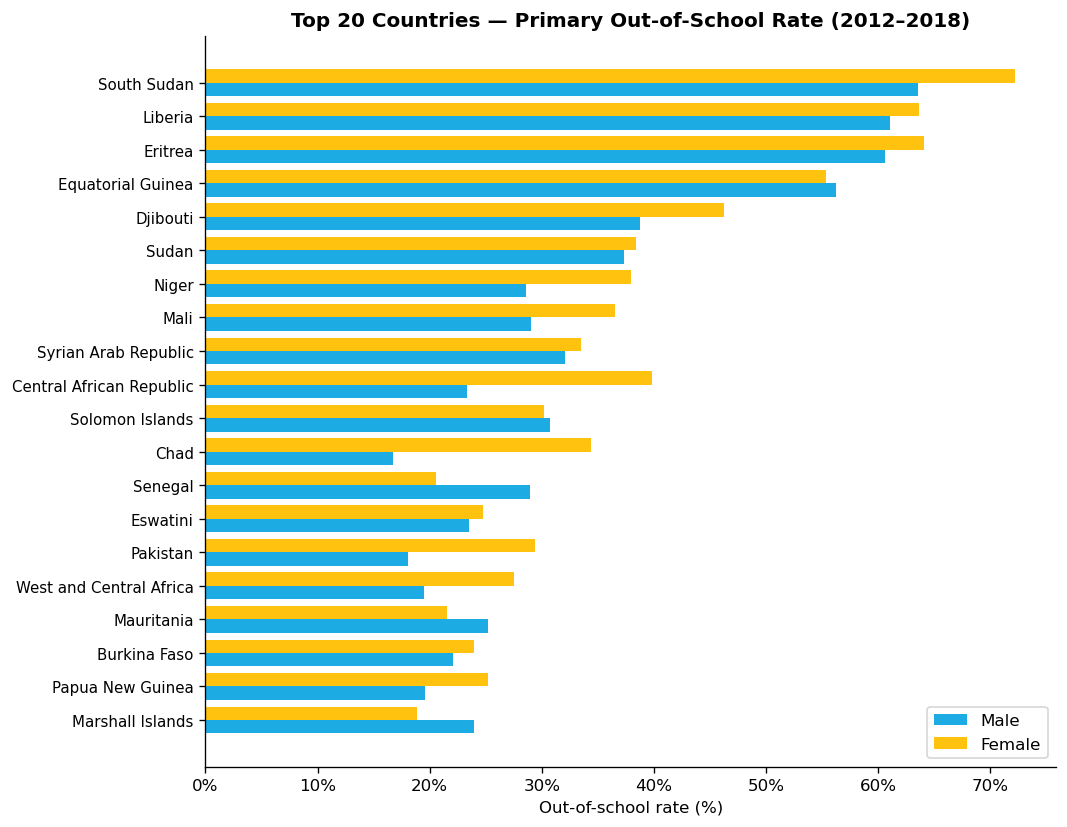

In [3]:
oos = data[['country', 'oos_primary_m', 'oos_primary_f']].dropna()
oos['avg'] = (oos['oos_primary_m'] + oos['oos_primary_f']) / 2
top20 = oos.nlargest(20, 'avg').sort_values('avg')

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(top20))
ax.barh(y - 0.2, top20['oos_primary_m'], 0.4, label='Male',   color=UNICEF_BLUE)
ax.barh(y + 0.2, top20['oos_primary_f'], 0.4, label='Female', color=UNICEF_YELLOW)
ax.set_yticks(y)
ax.set_yticklabels(top20['country'], fontsize=9)
ax.set_xlabel('Out-of-school rate (%)')
ax.set_title('Top 20 Countries — Primary Out-of-School Rate (2012–2018)', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

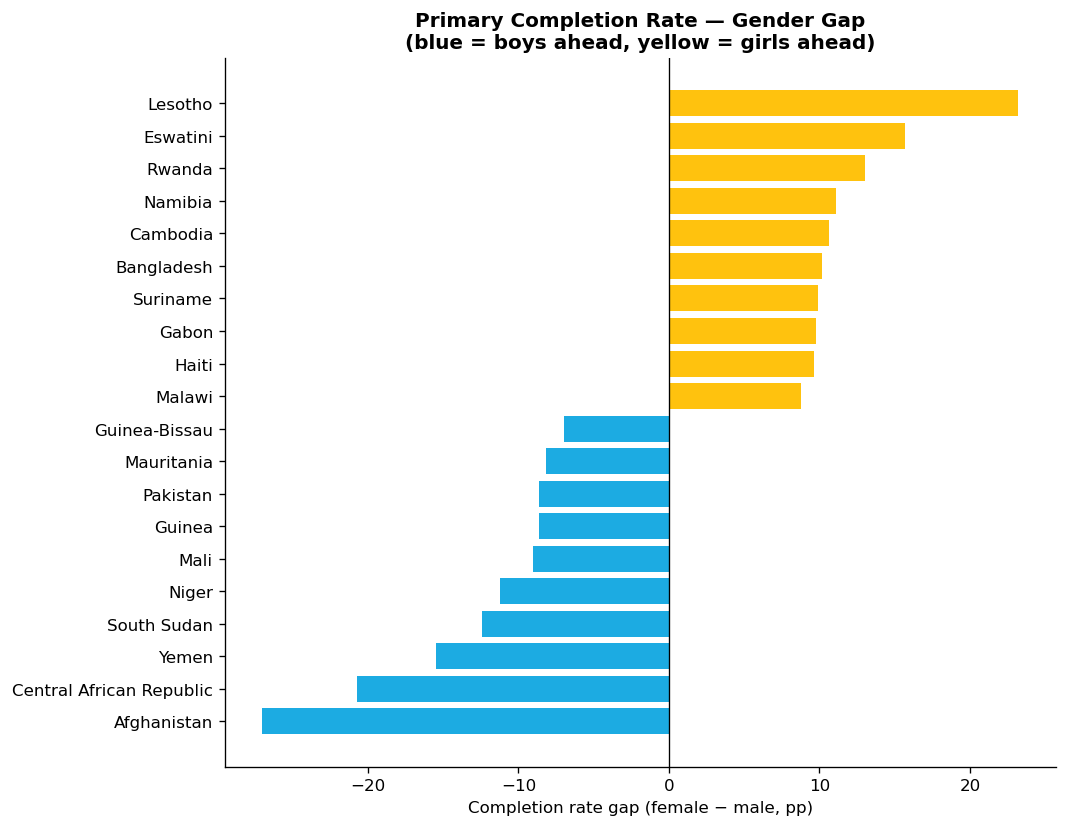

In [4]:
comp = data[['country', 'completion_primary_m', 'completion_primary_f']].dropna()
comp['gap'] = comp['completion_primary_f'] - comp['completion_primary_m']

extremes = pd.concat([
    comp.nsmallest(10, 'gap'),
    comp.nlargest(10, 'gap')
]).drop_duplicates().sort_values('gap')

colors = [UNICEF_BLUE if g < 0 else UNICEF_YELLOW for g in extremes['gap']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(extremes['country'], extremes['gap'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Completion rate gap (female − male, pp)')
ax.set_title('Primary Completion Rate — Gender Gap\n(blue = boys ahead, yellow = girls ahead)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

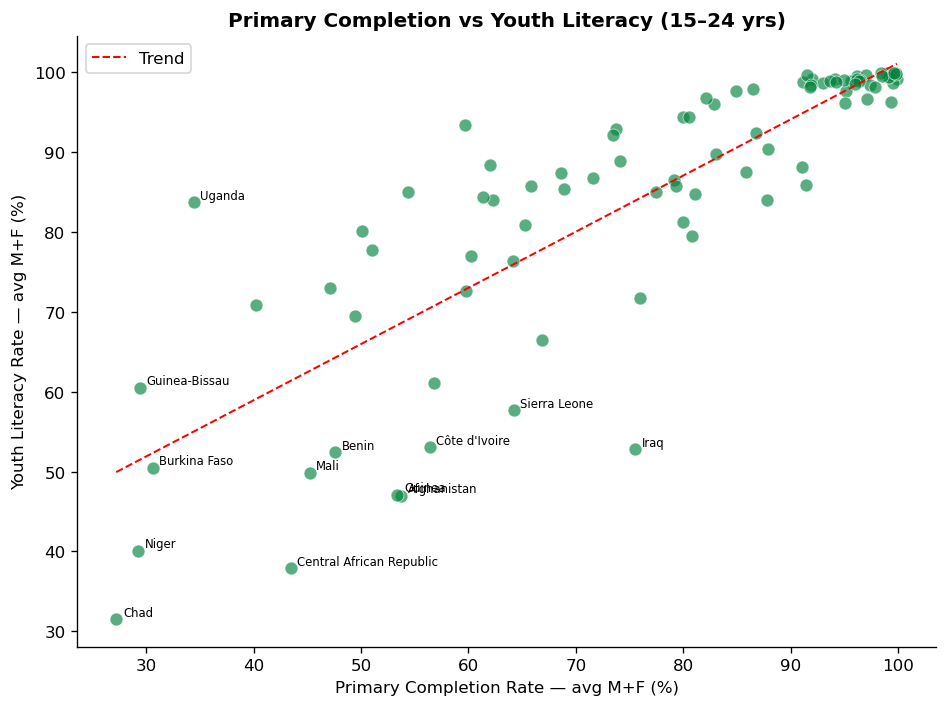

In [5]:
scatter = data[['country', 'completion_primary_m', 'completion_primary_f',
                'literacy_m', 'literacy_f']].dropna()
scatter['completion_avg'] = (scatter['completion_primary_m'] + scatter['completion_primary_f']) / 2
scatter['literacy_avg']   = (scatter['literacy_m'] + scatter['literacy_f']) / 2

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scatter['completion_avg'], scatter['literacy_avg'],
           alpha=0.65, color=UNICEF_GREEN, edgecolors='white', linewidths=0.5, s=60)

for _, row in scatter.iterrows():
    if row['literacy_avg'] < 60 or row['completion_avg'] < 40:
        ax.annotate(row['country'], (row['completion_avg'], row['literacy_avg']),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')

m, b = np.polyfit(scatter['completion_avg'], scatter['literacy_avg'], 1)
x_line = np.linspace(scatter['completion_avg'].min(), scatter['completion_avg'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.2, linestyle='--', label='Trend')

ax.set_xlabel('Primary Completion Rate — avg M+F (%)')
ax.set_ylabel('Youth Literacy Rate — avg M+F (%)')
ax.set_title('Primary Completion vs Youth Literacy (15–24 yrs)', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

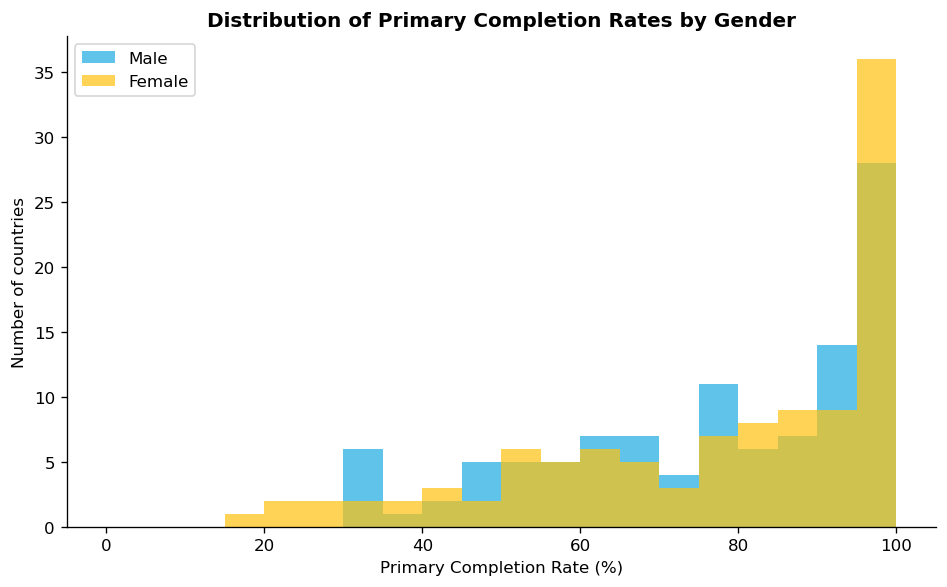

Median completion — Male: 80.3%  Female: 84.9%


In [6]:
comp_all = data[['completion_primary_m', 'completion_primary_f']].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 100, 21)
ax.hist(comp_all['completion_primary_m'], bins=bins, alpha=0.7, label='Male',   color=UNICEF_BLUE)
ax.hist(comp_all['completion_primary_f'], bins=bins, alpha=0.7, label='Female', color=UNICEF_YELLOW)
ax.set_xlabel('Primary Completion Rate (%)')
ax.set_ylabel('Number of countries')
ax.set_title('Distribution of Primary Completion Rates by Gender', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median completion — Male: {comp_all['completion_primary_m'].median():.1f}%  "
      f"Female: {comp_all['completion_primary_f'].median():.1f}%")